# Training Performance Audit (TensorBoard)

This notebook audits model-training dynamics from TensorBoard logs in
`./artifacts/tensorboard_logs`.

It provides:
- programmatic scalar extraction,
- training vs validation loss curves,
- overfitting / underfitting diagnostics,
- learning-rate schedule checks,
- early-stopping consistency checks.


In [6]:
from __future__ import annotations

from pathlib import Path
import re
import json
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Ensure plots render inside notebook output.
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

sns.set_theme(style='whitegrid', context='paper')
plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})


In [7]:
# Configuration
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent

TB_LOG_DIR = REPO_ROOT / 'artifacts/tensorboard_logs'
RUN_ID = None  # e.g. '2026-04-20T15-36-58Z'; None -> latest by lexical order

# Focus plots on these target families (editable):
TARGET_FILTER_PATTERNS = [
    r'^da_target_da_price$',
    r'afrr_.*(activation_rate|spread|capacity|activation_price)',
]

print('TB_LOG_DIR:', TB_LOG_DIR)


TB_LOG_DIR: /Users/leori/Code/energyTrading/artifacts/tensorboard_logs


In [8]:
try:
    from tensorboard.backend.event_processing import event_accumulator
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        'tensorboard is required for this notebook. Install with: pip install tensorboard'
    ) from exc


def pick_run_dir(tb_root: Path, run_id: str | None = None) -> Path:
    if not tb_root.exists():
        raise FileNotFoundError(f'TensorBoard log root not found: {tb_root}')
    if run_id:
        rd = tb_root / run_id
        if not rd.exists():
            raise FileNotFoundError(f'Run directory not found: {rd}')
        return rd
    candidates = sorted([p for p in tb_root.iterdir() if p.is_dir()])
    if not candidates:
        raise FileNotFoundError(f'No run directories found under: {tb_root}')
    return candidates[-1]


def pick_scalar_tag(tags: list[str], patterns: list[str]) -> str | None:
    for pat in patterns:
        rx = re.compile(pat, re.IGNORECASE)
        for t in tags:
            if rx.search(t):
                return t
    return None


def extract_scalars_for_target(target_dir: Path) -> pd.DataFrame:
    ea = event_accumulator.EventAccumulator(str(target_dir), size_guidance={'scalars': 0})
    ea.Reload()
    tags = ea.Tags().get('scalars', [])

    train_tag = pick_scalar_tag(tags, [r'train.*loss.*epoch', r'train.*loss', r'loss/train', r'train_loss'])
    val_tag = pick_scalar_tag(tags, [r'val.*loss.*epoch', r'valid.*loss', r'loss/val', r'val_loss'])
    lr_tag = pick_scalar_tag(tags, [r'learning_rate', r'\blr\b', r'optimizer.*/lr'])

    rows = []
    for split, tag in [('train', train_tag), ('val', val_tag), ('lr', lr_tag)]:
        if tag is None:
            continue
        for e in ea.Scalars(tag):
            rows.append({
                'target': target_dir.name,
                'split': split,
                'tag': tag,
                'step': int(e.step),
                'value': float(e.value),
                'wall_time': float(e.wall_time),
            })

    return pd.DataFrame(rows), {'train_tag': train_tag, 'val_tag': val_tag, 'lr_tag': lr_tag, 'tags': tags}


def classify_training(train_vals: np.ndarray, val_vals: np.ndarray) -> str:
    if len(train_vals) < 8 or len(val_vals) < 8:
        return 'Insufficient Data'
    val_best = float(np.min(val_vals))
    val_final = float(val_vals[-1])
    train_final = float(train_vals[-1])
    best_idx = int(np.argmin(val_vals))

    if best_idx < len(val_vals) - 3 and val_final > val_best * 1.05 and train_final <= float(np.min(train_vals[max(0, best_idx-1):])):
        return 'Overfitting Detected'

    tail_n = max(3, int(0.2 * len(val_vals)))
    val_tail = val_vals[-tail_n:]
    if float(np.max(val_tail) - np.min(val_tail)) <= max(1e-8, 0.01 * max(abs(val_final), 1.0)) and val_final > train_final * 0.95:
        return 'Underfitting Suspected'

    if len(val_tail) >= 4:
        diffs = np.diff(val_tail)
        if float(np.std(diffs)) > max(1e-8, 0.05 * max(abs(val_final), 1.0)):
            return 'Unstable'

    return 'Converged'


In [9]:
run_dir = pick_run_dir(TB_LOG_DIR, RUN_ID)
print('Using run_dir:', run_dir)

target_dirs = sorted([p for p in run_dir.iterdir() if p.is_dir()])
if not target_dirs:
    raise RuntimeError(f'No target subdirectories in: {run_dir}')

rx_list = [re.compile(p, re.IGNORECASE) for p in TARGET_FILTER_PATTERNS]
def keep_target(name: str) -> bool:
    return any(rx.search(name) for rx in rx_list)

target_dirs = [p for p in target_dirs if keep_target(p.name)] or target_dirs
print('Targets selected:', len(target_dirs))
for p in target_dirs:
    print(' -', p.name)


Using run_dir: /Users/leori/Code/energyTrading/artifacts/tensorboard_logs/2026-04-20T15-36-58Z
Targets selected: 7
 - afrr_target_afrr_activation_price_vwap_neg
 - afrr_target_afrr_activation_price_vwap_pos
 - afrr_target_afrr_activation_rate_neg
 - afrr_target_afrr_activation_rate_pos
 - afrr_target_afrr_capacity_price_neg
 - afrr_target_afrr_capacity_price_pos
 - da_target_da_price


In [10]:
all_frames = []
meta = {}
for td in target_dirs:
    df_t, m = extract_scalars_for_target(td)
    all_frames.append(df_t)
    meta[td.name] = m

scalars = pd.concat(all_frames, ignore_index=True) if all_frames else pd.DataFrame()
print('Scalar rows:', len(scalars))

if not scalars.empty:
    display(scalars.head())

meta_df = pd.DataFrame([
    {
        'target': k,
        'train_tag': v.get('train_tag'),
        'val_tag': v.get('val_tag'),
        'lr_tag': v.get('lr_tag'),
        'n_tags': len(v.get('tags', [])),
    }
    for k, v in meta.items()
]).sort_values('target').reset_index(drop=True)

print('Tag detection summary:')
display(meta_df)


Scalar rows: 256


,target,split,tag,step,value,wall_time
0,afrr_target_afrr_activation_price_vwap_neg,train,train_loss_epoch,204,256.309021,1.776714e+09
1,afrr_target_afrr_activation_price_vwap_neg,train,train_loss_epoch,409,208.030731,1.776714e+09
2,afrr_target_afrr_activation_price_vwap_neg,train,train_loss_epoch,614,176.133209,1.776714e+09
3,afrr_target_afrr_activation_price_vwap_neg,train,train_loss_epoch,819,150.448364,1.776715e+09
4,afrr_target_afrr_activation_price_vwap_neg,train,train_loss_epoch,1024,131.744263,1.776715e+09


Tag detection summary:


,target,train_tag,val_tag,lr_tag,n_tags
0,afrr_target_afrr_activation_price_vwap_neg,train_loss_epoch,val_loss,None,9
1,afrr_target_afrr_activation_price_vwap_pos,train_loss_epoch,val_loss,None,9
2,afrr_target_afrr_activation_rate_neg,train_loss_epoch,val_loss,None,9
3,afrr_target_afrr_activation_rate_pos,train_loss_epoch,val_loss,None,9
4,afrr_target_afrr_capacity_price_neg,train_loss_epoch,val_loss,None,9
5,afrr_target_afrr_capacity_price_pos,train_loss_epoch,val_loss,None,9
6,da_target_da_price,train_loss_epoch,val_loss,None,9


In [11]:
# Per-target diagnostics table
rows = []
for tgt in sorted(scalars['target'].unique() if not scalars.empty else []):
    sub = scalars[scalars['target'] == tgt]
    tr = sub[sub['split'] == 'train'].sort_values('step')
    va = sub[sub['split'] == 'val'].sort_values('step')

    if tr.empty or va.empty:
        rows.append({'target': tgt, 'status': 'Missing Loss Scalars'})
        continue

    train_vals = tr['value'].to_numpy(dtype=float)
    val_vals = va['value'].to_numpy(dtype=float)
    best_idx = int(np.argmin(val_vals))
    best_epoch = int(va.iloc[best_idx]['step'])

    status = classify_training(train_vals, val_vals)

    # Early-stopping validation: best checkpoint should be global min val loss.
    early_stopping_ok = bool(np.isclose(val_vals[best_idx], np.min(val_vals)))

    rows.append({
        'target': tgt,
        'final_train_loss': float(train_vals[-1]),
        'final_val_loss': float(val_vals[-1]),
        'best_epoch': best_epoch,
        'total_epochs': int(max(tr['step'].max(), va['step'].max()) + 1),
        'status': status,
        'early_stopping_global_min_ok': early_stopping_ok,
        'val_minus_train_final': float(val_vals[-1] - train_vals[-1]),
    })

summary_df = pd.DataFrame(rows).sort_values('target').reset_index(drop=True)
summary_df


,target,final_train_loss,final_val_loss,best_epoch,total_epochs,status,early_stopping_global_min_ok,val_minus_train_final
0,afrr_target_afrr_activation_price_vwap_neg,76.995285,184.954071,204,3280,Overfitting Detected,True,107.958786
1,afrr_target_afrr_activation_price_vwap_pos,112.994568,282.441772,204,3280,Overfitting Detected,True,169.447205
2,afrr_target_afrr_activation_rate_neg,0.003174,0.013777,204,3280,Overfitting Detected,True,0.010602
3,afrr_target_afrr_activation_rate_pos,0.002772,0.008072,204,3280,Overfitting Detected,True,0.005300
4,afrr_target_afrr_capacity_price_neg,3.180076,7.636285,204,3280,Overfitting Detected,True,4.456209
5,afrr_target_afrr_capacity_price_pos,2.839600,9.221743,204,3280,Overfitting Detected,True,6.382143
6,da_target_da_price,4.428031,13.735420,3484,6560,Converged,True,9.307389


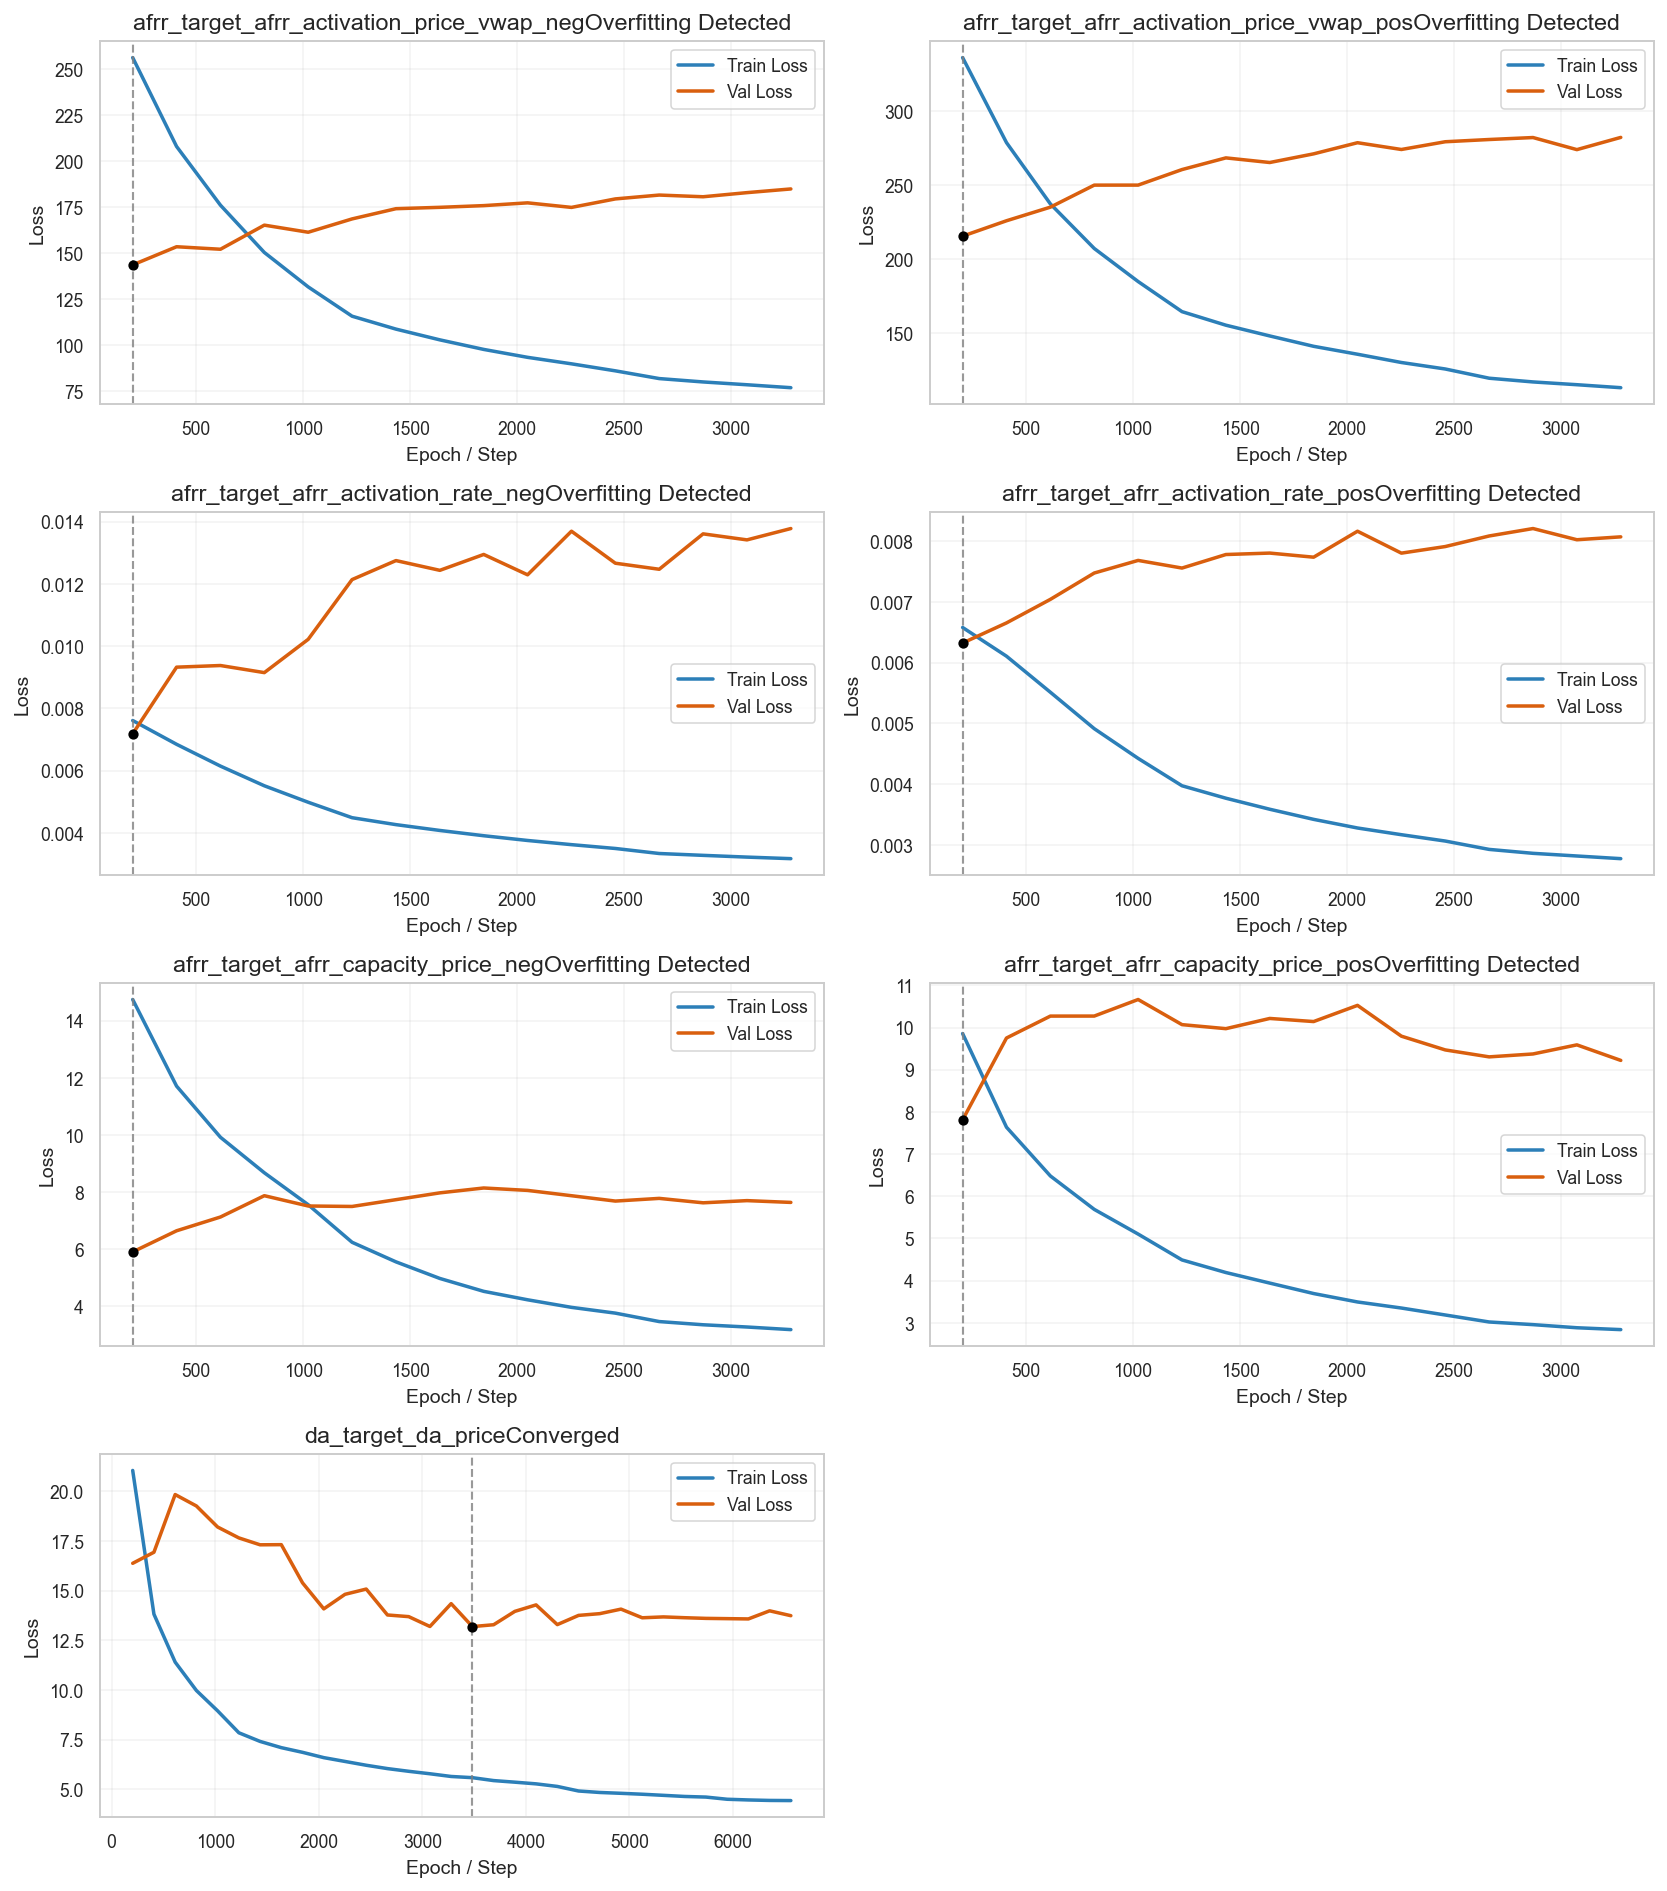

In [12]:
# Plot training vs validation loss curves
if summary_df.empty:
    print('No summary rows to plot. Check tag detection table in previous cell.')
else:
    n = len(summary_df)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.4 * nrows), sharex=False)
    axes = np.atleast_1d(axes).reshape(nrows, ncols)

    for i, tgt in enumerate(summary_df['target'].tolist()):
        r, c = divmod(i, ncols)
        ax = axes[r, c]
        sub = scalars[scalars['target'] == tgt]
        tr = sub[sub['split'] == 'train'].sort_values('step')
        va = sub[sub['split'] == 'val'].sort_values('step')
        ax.plot(tr['step'], tr['value'], label='Train Loss', linewidth=1.8, color='#2C7FB8')
        ax.plot(va['step'], va['value'], label='Val Loss', linewidth=1.8, color='#D95F0E')
        best_idx = int(np.argmin(va['value'].to_numpy(dtype=float)))
        best_step = int(va.iloc[best_idx]['step'])
        best_val = float(va.iloc[best_idx]['value'])
        ax.axvline(best_step, color='gray', linestyle='--', linewidth=1.1, alpha=0.8)
        ax.scatter([best_step], [best_val], color='black', s=20, zorder=3)
        st = summary_df.loc[summary_df['target'] == tgt, 'status'].iloc[0]
        ax.set_title(f"{tgt}{st}")
        ax.set_xlabel('Epoch / Step')
        ax.set_ylabel('Loss')
        ax.legend(loc='best')
        ax.grid(alpha=0.25)

    # hide unused axes
    for j in range(len(summary_df), nrows*ncols):
        r, c = divmod(j, ncols)
        axes[r, c].axis('off')

    plt.tight_layout()
    display(fig)
    plt.close(fig)


In [13]:
# Learning-rate schedule audit
lr_df = scalars[scalars['split'] == 'lr'].copy() if not scalars.empty else pd.DataFrame()
if lr_df.empty:
    print('No learning-rate scalar found in logs.')
else:
    n = len(lr_df['target'].unique())
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.0 * nrows), sharex=False)
    axes = np.atleast_1d(axes).reshape(nrows, ncols)

    for i, tgt in enumerate(sorted(lr_df['target'].unique())):
        r, c = divmod(i, ncols)
        ax = axes[r, c]
        sub = lr_df[lr_df['target'] == tgt].sort_values('step')
        ax.plot(sub['step'], sub['value'], color='#238B45', linewidth=1.8)
        ax.set_title(tgt)
        ax.set_xlabel('Epoch / Step')
        ax.set_ylabel('Learning Rate')
        ax.grid(alpha=0.25)

    for j in range(n, nrows*ncols):
        r, c = divmod(j, ncols)
        axes[r, c].axis('off')

    plt.tight_layout()
    display(fig)
    plt.close(fig)


No learning-rate scalar found in logs.


In [14]:
# JSON-ready audit export for appendix
out = {
    'run_dir': str(run_dir),
    'n_targets': int(len(summary_df)),
    'targets': summary_df.to_dict(orient='records'),
}

out_path = REPO_ROOT / 'data/reports/model_audit/training_performance_audit.json'
out_path.parent.mkdir(parents=True, exist_ok=True)
out_path.write_text(json.dumps(out, indent=2), encoding='utf-8')
print('Wrote:', out_path)


Wrote: /Users/leori/Code/energyTrading/data/reports/model_audit/training_performance_audit.json
